# Computational Verification: Interval Decomposition of Persistence Modules via Type $A_n$ Quiver Representations

Supplementary notebook for

> **"Representations of Type $A_n$ Quivers and Persistence Modules: Interval Decomposition with Computational Verification on Point Cloud Data"**

### What this notebook verifies, and why it is a verification

GUDHI produces a barcode by column-reducing the boundary matrix of the filtered complex. That reduction *is* an interval-decomposition algorithm. Comparing "the GUDHI barcode" with "the interval decomposition" is therefore circular unless the interval decomposition is obtained some other way.

Here the two sides are computed independently.

| Route | How the intervals are obtained | Shares code with GUDHI? |
|---|---|---|
| **A** | Persistence module built by elementary means (union-find for $H_0$; spanning forests and GF(2) elimination for $H_1$), then decomposed by the reduction algorithm of Proposition 2 | no |
| **B** | Same module, intervals recovered from the rank invariant $r(i,j)=\operatorname{rank}(\varphi_{j-1}\cdots\varphi_i)$ by inclusion–exclusion — no basis reduction, no ordering | no |
| **C** | GUDHI barcode, discretised to the same grid of scales | — |

Agreement of A, B and C is a test with a possible outcome of failure, which is what the manuscript's Section 5 currently lacks.

### Contents

1. Positive roots of $q_{A_n}$ — brute-force check of Proposition 1
2. The reduction algorithm of Proposition 2, and the uniqueness of Theorem 3
3. Experiment 1 — the unit square (four routes, including the hand computation of Section 4)
4. Experiment 2 — noisy circle
5. Experiment 3 — two Gaussian clusters
6. A reproducibility note on the random number generator
7. Summary

Requirements: `gudhi`, `numpy`, `matplotlib`, `nbformat`. Install with `pip install gudhi numpy matplotlib`.

In [2]:
import itertools, platform, time
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import gudhi
import gudhi.persistence_graphical_tools as gpt

gpt._gudhi_matplotlib_use_tex = False   # avoid the "usetex requires TeX" warning

print("python", platform.python_version(), "| numpy", np.__version__,
      "| gudhi", gudhi.__version__)

python 3.11.5 | numpy 1.26.4 | gudhi 3.13.0


Each experiment below gets **its own generator**. In the earlier draft of this notebook a single
`np.random.default_rng(2026)` was shared by Experiments 2 and 3, which makes the data of
Experiment 3 depend on how many numbers Experiment 2 had already consumed; see Section 6.

In [5]:
SEED_CIRCLE   = 20260002
SEED_CLUSTERS = 20260003
SEED_TRIALS   = 20260007

---
## 0. The two library modules

The next two cells write out `qrep.py` and `tda.py`, the files that accompany the paper as
supplementary material. Writing them from the notebook keeps the notebook and the supplement in
sync — there is a single source of truth.

`qrep.py` is pure representation theory of $\vec{A}_n$ over $\mathrm{GF}(p)$: the quadratic form,
its roots, the reduction algorithm of Proposition 2, and the rank invariant.

In [8]:
%%writefile qrep.py
"""
qrep.py -- Representations of the equioriented quiver A_n over a finite field GF(p).

Self-contained implementation, independent of any topological-data-analysis library:

  * qA(x)                      : the quadratic form q_{A_n} of Definition 2
  * positive_roots_bruteforce  : brute-force enumeration of the roots (checks Proposition 1)
  * interval_vectors           : the vectors e_{[b,d]}
  * decompose                  : the reduction algorithm of Proposition 2, returning the
                                 multiset of intervals of Theorem 3
  * rank_invariant             : the ranks of all composite maps
  * intervals_from_rank_invariant : the intervals recovered by inclusion-exclusion
                                 (a second, logically independent route to the barcode)
  * reconstruct                : rebuild the matrices from a multiset of intervals

Conventions.  A persistence module of length n is given as a list of n-1 matrices
`phis`, where phis[i-1] is the matrix of phi_i : V_i -> V_{i+1} in the chosen bases,
of shape (dim V_{i+1}, dim V_i).  Indices b, d in an interval [b, d] are 1-based, so
1 <= b <= d <= n, matching the notation of the paper.
"""

from __future__ import annotations

import itertools
from collections import Counter

import numpy as np

__all__ = [
    "qA", "interval_vector", "interval_vectors", "positive_roots_bruteforce",
    "rref", "rank", "decompose", "rank_invariant", "intervals_from_rank_invariant",
    "reconstruct", "random_module",
]


# ---------------------------------------------------------------------------
# 1. The quadratic form of A_n and its roots  (Section 3.2 of the paper)
# ---------------------------------------------------------------------------

def qA(x) -> int:
    """q_{A_n}(x) = sum x_i^2 - sum x_i x_{i+1}  (equation (1))."""
    x = np.asarray(x, dtype=np.int64)
    return int(np.sum(x * x) - np.sum(x[:-1] * x[1:]))


def interval_vector(n: int, b: int, d: int) -> np.ndarray:
    """e_{[b,d]} = e_b + e_{b+1} + ... + e_d, with 1-based b <= d."""
    v = np.zeros(n, dtype=np.int64)
    v[b - 1:d] = 1
    return v


def interval_vectors(n: int):
    """All interval vectors e_{[b,d]}, 1 <= b <= d <= n."""
    return {(b, d): interval_vector(n, b, d) for b in range(1, n + 1)
            for d in range(b, n + 1)}


def positive_roots_bruteforce(n: int, bound: int = 2):
    """Every x in {-bound,...,bound}^n with q_{A_n}(x) = 1 and x >= 0.

    Proposition 1 claims this set is exactly the set of interval vectors.  The
    bound is a search window only: Lemma 2 forces |x_i| <= 1 for any root, so
    bound >= 1 already gives the complete answer; we take bound = 2 so that the
    enumeration also *observes* that no root has an entry of modulus 2.
    """
    roots = []
    for x in itertools.product(range(-bound, bound + 1), repeat=n):
        if qA(x) == 1:
            roots.append(np.array(x, dtype=np.int64))
    positive = [r for r in roots if np.all(r >= 0) and np.any(r != 0)]
    return roots, positive


# ---------------------------------------------------------------------------
# 2. Linear algebra over GF(p)
# ---------------------------------------------------------------------------

def _inv_mod(a: int, p: int) -> int:
    return pow(int(a) % p, p - 2, p)


def rref(A: np.ndarray, p: int):
    """Reduced row echelon form over GF(p).  Returns (R, pivot_columns)."""
    R = np.asarray(A, dtype=np.int64).copy() % p
    rows, cols = R.shape
    pivots = []
    r = 0
    for c in range(cols):
        if r >= rows:
            break
        nz = np.nonzero(R[r:, c])[0]
        if nz.size == 0:
            continue
        i = r + int(nz[0])
        if i != r:
            R[[r, i]] = R[[i, r]]
        R[r] = (R[r] * _inv_mod(R[r, c], p)) % p
        col = R[:, c].copy()
        col[r] = 0
        R = (R - np.outer(col, R[r])) % p
        pivots.append(c)
        r += 1
    return R, pivots


def rank(A: np.ndarray, p: int) -> int:
    if A.size == 0:
        return 0
    return len(rref(A, p)[1])


def _reduce_against(vec: np.ndarray, pivots: dict, p: int) -> np.ndarray:
    """Reduce `vec` against a dict {pivot_row: pivot_vector} (pivot rows are the
    first nonzero row of each pivot vector, normalised to 1)."""
    v = vec.copy() % p
    while True:
        nz = np.nonzero(v)[0]
        if nz.size == 0:
            return v
        r = int(nz[0])
        if r not in pivots:
            return v
        v = (v - v[r] * pivots[r]) % p


# ---------------------------------------------------------------------------
# 3. The decomposition algorithm  (Proposition 2 / Theorem 3)
# ---------------------------------------------------------------------------

def decompose(phis, p: int = 2, tie_break=None):
    """Interval decomposition of the persistence module given by `phis`.

    Returns a sorted list of 1-based intervals [b, d] (with multiplicity).

    The algorithm is the forward simultaneous reduction of Proposition 2.  At
    each index we hold one basis vector per currently alive bar.  Images under
    phi_i are reduced *in order of increasing birth*, so that when a linear
    dependency appears it is the youngest bar that is killed (the elder rule);
    subtracting an older basis vector from a younger one is exactly the
    admissible basis change of the proof sketch, since the older vector is
    defined at every index where the younger one is.  Basis vectors of V_{i+1}
    not reached by the image start new bars.

    `tie_break` optionally permutes the processing order *within* a group of
    equal births; the resulting multiset of intervals must not depend on it.
    """
    phis = [np.asarray(M, dtype=np.int64) % p for M in phis]
    n = len(phis) + 1
    if n == 1:
        raise ValueError("need at least one map; use length >= 2")
    dims = [phis[0].shape[1]] + [M.shape[0] for M in phis]
    for i, M in enumerate(phis):
        if M.shape != (dims[i + 1], dims[i]):
            raise ValueError(f"phi_{i+1} has shape {M.shape}, expected "
                             f"{(dims[i+1], dims[i])}")

    # active bars at index 1: the standard basis of V_1, all born at index 1
    active = [(1, np.eye(dims[0], dtype=np.int64)[:, k]) for k in range(dims[0])]
    bars = []

    for i in range(1, n):                       # apply phi_i : V_i -> V_{i+1}
        M = phis[i - 1]
        idx = sorted(range(len(active)), key=lambda k: active[k][0])
        if tie_break is not None:
            idx = tie_break(idx, [active[k][0] for k in idx])
        pivots, survivors = {}, []
        for k in idx:
            b, w = active[k]
            x = _reduce_against((M @ w) % p, pivots, p)
            if not x.any():
                bars.append((b, i))             # the bar [b, i] dies here
            else:
                r = int(np.nonzero(x)[0][0])
                x = (x * _inv_mod(x[r], p)) % p
                pivots[r] = x
                survivors.append((b, x))
        for r0 in range(dims[i]):               # cokernel: bars born at i+1
            e = np.zeros(dims[i], dtype=np.int64)
            e[r0] = 1
            x = _reduce_against(e, pivots, p)
            if x.any():
                r = int(np.nonzero(x)[0][0])
                x = (x * _inv_mod(x[r], p)) % p
                pivots[r] = x
                survivors.append((i + 1, x))
        active = survivors

    for b, _ in active:
        bars.append((b, n))
    return sorted(bars)


# ---------------------------------------------------------------------------
# 4. The rank invariant: a second, independent route to the same intervals
# ---------------------------------------------------------------------------

def rank_invariant(phis, p: int = 2):
    """R[(i, j)] = rank(phi_{j-1} o ... o phi_i : V_i -> V_j) for i <= j."""
    phis = [np.asarray(M, dtype=np.int64) % p for M in phis]
    n = len(phis) + 1
    dims = [phis[0].shape[1]] + [M.shape[0] for M in phis]
    R = {}
    for i in range(1, n + 1):
        C = np.eye(dims[i - 1], dtype=np.int64)
        R[(i, i)] = dims[i - 1]
        for j in range(i + 1, n + 1):
            C = (phis[j - 2] @ C) % p
            R[(i, j)] = rank(C, p) if C.size else 0
    return R


def intervals_from_rank_invariant(phis, p: int = 2):
    """Multiplicity of [b, d] is R(b,d) - R(b-1,d) - R(b,d+1) + R(b-1,d+1).

    This uses only ranks of composite maps -- no basis reduction, no choice of
    ordering -- so agreement with `decompose` is a genuine cross-check rather
    than a restatement.
    """
    n = len(phis) + 1
    R = rank_invariant(phis, p)

    def r(i, j):
        if i < 1 or j > n or i > j:
            return 0
        return R[(i, j)]

    out = []
    for b in range(1, n + 1):
        for d in range(b, n + 1):
            m = r(b, d) - r(b - 1, d) - r(b, d + 1) + r(b - 1, d + 1)
            if m < 0:
                raise AssertionError(f"negative multiplicity at [{b},{d}]")
            out.extend([(b, d)] * m)
    return sorted(out)


# ---------------------------------------------------------------------------
# 5. Reconstruction and random test modules
# ---------------------------------------------------------------------------

def reconstruct(bars, n: int):
    """Direct sum of the interval modules I[b, d]: returns the list of matrices."""
    bars = list(bars)
    dims = [sum(1 for b, d in bars if b <= i <= d) for i in range(1, n + 1)]
    phis = []
    for i in range(1, n):
        M = np.zeros((dims[i], dims[i - 1]), dtype=np.int64)
        rows = [k for k, (b, d) in enumerate(bars) if b <= i + 1 <= d]
        cols = [k for k, (b, d) in enumerate(bars) if b <= i <= d]
        for c, k in enumerate(cols):
            if k in rows:
                M[rows.index(k), c] = 1
        phis.append(M)
    return phis


def random_module(rng, n: int, p: int = 2, max_dim: int = 5):
    """A random persistence module: random dimensions, random matrices."""
    dims = [int(rng.integers(0, max_dim + 1)) for _ in range(n)]
    return [rng.integers(0, p, size=(dims[i + 1], dims[i])).astype(np.int64)
            for i in range(n - 1)]

Overwriting qrep.py


`tda.py` builds the persistence module of a Vietoris–Rips filtration **without any
persistent-homology library**: connected components by union-find for $H_0$, and cycles modulo
boundaries by spanning forests plus GF(2) bitmask elimination for $H_1$.

In [11]:
%%writefile tda.py
"""
tda.py -- Building the persistence module of a Vietoris-Rips filtration by hand.

Nothing here uses a persistent-homology library.  The point is to obtain the
matrices phi_i : H_p(K_i) -> H_p(K_{i+1}) by elementary means (union-find for
p = 0, spanning forests and GF(2) elimination for p = 1), so that the interval
decomposition computed by qrep.decompose can be compared with the barcode
produced by GUDHI's boundary-matrix reduction.  The two computations then share
no code and no algorithmic idea, which is what makes the comparison a test.

All of the p = 1 code works over GF(2), the coefficient field GUDHI uses by
default.
"""

from __future__ import annotations

import itertools
import numpy as np

__all__ = ["pairwise_distances", "distinct_distances", "h0_module", "h1_module",
           "discretise_barcode", "grid_from_distances"]


# ---------------------------------------------------------------------------
# geometry
# ---------------------------------------------------------------------------

def pairwise_distances(X: np.ndarray) -> np.ndarray:
    D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(-1))
    np.fill_diagonal(D, 0.0)
    return D


def distinct_distances(D: np.ndarray, tol: float = 1e-12):
    """The distinct values 0 = r_1 < r_2 < ... appearing as pairwise distances."""
    m = D.shape[0]
    vals = sorted({round(float(D[i, j]), 12)
                   for i in range(m) for j in range(i + 1, m)})
    out = [0.0]
    for v in vals:
        if v - out[-1] > tol:
            out.append(v)
    return out


def grid_from_distances(D: np.ndarray, n: int, rmax: float):
    """A uniform grid 0 = r_1 < ... < r_n = rmax of filtration scales."""
    return list(np.linspace(0.0, rmax, n))


# ---------------------------------------------------------------------------
# degree 0: connected components by union-find
# ---------------------------------------------------------------------------

class _UF:
    def __init__(self, m):
        self.p = list(range(m))

    def find(self, a):
        while self.p[a] != a:
            self.p[a] = self.p[self.p[a]]
            a = self.p[a]
        return a

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.p[rb] = ra
            return True
        return False


def _components(D, r, m):
    uf = _UF(m)
    for i in range(m):
        for j in range(i + 1, m):
            if D[i, j] <= r + 1e-12:
                uf.union(i, j)
    roots = {}
    label = []
    for i in range(m):
        r0 = uf.find(i)
        if r0 not in roots:
            roots[r0] = len(roots)
        label.append(roots[r0])
    return label, len(roots)


def h0_module(X: np.ndarray, grid):
    """The persistence module H_0(K_1) -> ... -> H_0(K_n) of the VR filtration.

    A basis of H_0(K_i) is the set of connected components of K_i; the induced
    map sends a component to the component of K_{i+1} containing it.  Returned
    as a list of 0-1 matrices over GF(2).
    """
    D = pairwise_distances(X)
    m = X.shape[0]
    labels, dims = [], []
    for r in grid:
        lab, k = _components(D, r, m)
        labels.append(lab)
        dims.append(k)
    phis = []
    for i in range(len(grid) - 1):
        M = np.zeros((dims[i + 1], dims[i]), dtype=np.int64)
        seen = set()
        for v in range(m):
            c, c2 = labels[i][v], labels[i + 1][v]
            if c not in seen:
                seen.add(c)
                M[c2, c] = 1
        phis.append(M)
    return phis, dims


# ---------------------------------------------------------------------------
# degree 1: cycles modulo boundaries over GF(2), with bitmask linear algebra
# ---------------------------------------------------------------------------

def _edges_triangles(D, m, rmax):
    edges, ediam = [], []
    for i in range(m):
        for j in range(i + 1, m):
            if D[i, j] <= rmax + 1e-12:
                edges.append((i, j))
                ediam.append(D[i, j])
    eindex = {e: k for k, e in enumerate(edges)}
    tris, tdiam = [], []
    for a, b, c in itertools.combinations(range(m), 3):
        d = max(D[a, b], D[a, c], D[b, c])
        if d <= rmax + 1e-12:
            tris.append((a, b, c))
            tdiam.append(d)
    return edges, np.array(ediam), eindex, tris, np.array(tdiam)


def _insert(pivots, mask, label):
    """Insert (mask, label) into a GF(2) echelon table keyed by lowest set bit.

    Returns (reduced_mask, reduced_label).  If reduced_mask is 0 the vector was
    already in the span and `reduced_label` expresses the relation.
    """
    while mask:
        low = mask & -mask
        b = low.bit_length() - 1
        if b not in pivots:
            pivots[b] = (mask, label)
            return 0, None
        pm, pl = pivots[b]
        mask ^= pm
        label ^= pl
    return 0, label


def _reduce(pivots, mask, label=0):
    while mask:
        low = mask & -mask
        b = low.bit_length() - 1
        if b not in pivots:
            return mask, label
        pm, pl = pivots[b]
        mask ^= pm
        label ^= pl
    return 0, label


def h1_module(X: np.ndarray, grid):
    """The persistence module H_1(K_1) -> ... -> H_1(K_n) over GF(2).

    For each scale: a basis of the cycle space Z_1 is given by the fundamental
    cycles of the non-tree edges of a spanning forest; the boundary space B_1 is
    spanned by the triangle boundaries; a basis of H_1 = Z_1 / B_1 is obtained
    by inserting the fundamental cycles into an echelon table already containing
    B_1 and keeping those that are independent.  The induced map is computed by
    reducing each generator of H_1(K_i) in the table of K_{i+1} while tracking
    which generators of H_1(K_{i+1}) are used.
    """
    D = pairwise_distances(X)
    m = X.shape[0]
    rmax = max(grid)
    edges, ediam, eindex, tris, tdiam = _edges_triangles(D, m, rmax)

    gens, tables = [], []
    for r in grid:
        # --- boundary space B_1 at this scale
        piv = {}
        for t, dia in zip(tris, tdiam):
            if dia <= r + 1e-12:
                a, b, c = t
                mask = ((1 << eindex[(a, b)]) | (1 << eindex[(a, c)])
                        | (1 << eindex[(b, c)]))
                _insert(piv, mask, 0)
        # --- spanning forest of the 1-skeleton, then fundamental cycles
        uf = _UF(m)
        tree = []
        nontree = []
        for k, (i, j) in enumerate(edges):
            if ediam[k] <= r + 1e-12:
                (tree if uf.union(i, j) else nontree).append(k)
        adj = {v: [] for v in range(m)}
        for k in tree:
            i, j = edges[k]
            adj[i].append((j, k))
            adj[j].append((i, k))
        parent = {}
        depth = {}
        for s in range(m):
            if s in parent:
                continue
            parent[s] = (None, None)
            depth[s] = 0
            stack = [s]
            while stack:
                v = stack.pop()
                for w, k in adj[v]:
                    if w not in parent:
                        parent[w] = (v, k)
                        depth[w] = depth[v] + 1
                        stack.append(w)

        def path_mask(u, v):
            mask = 0
            while u != v:
                if depth[u] < depth[v]:
                    u, v = v, u
                pu, ku = parent[u]
                mask ^= (1 << ku)
                u = pu
            return mask

        g = []
        for k in nontree:
            i, j = edges[k]
            mask = (1 << k) ^ path_mask(i, j)
            _, relation = _insert(piv, mask, 1 << len(g))
            if relation is None:        # newly inserted: independent modulo B_1
                g.append(mask)
        # `piv` now holds B_1 (label 0) followed by the generators (labels
        # 1 << idx), so every stored pivot is congruent, modulo B_1, to the
        # combination of generators recorded in its label.
        gens.append(g)
        tables.append(piv)

    phis = []
    for i in range(len(grid) - 1):
        M = np.zeros((len(gens[i + 1]), len(gens[i])), dtype=np.int64)
        for c, mask in enumerate(gens[i]):
            left, lab = _reduce(tables[i + 1], mask, 0)
            assert left == 0, "a cycle of K_i is not a cycle of K_{i+1}"
            for j in range(len(gens[i + 1])):
                if (lab >> j) & 1:
                    M[j, c] = 1
        phis.append(M)
    return phis, [len(g) for g in gens]


# ---------------------------------------------------------------------------
# comparing with a barcode given in scale coordinates
# ---------------------------------------------------------------------------

def discretise_barcode(bars, grid, tol=1e-9):
    """Convert bars [birth, death) in scale coordinates to index intervals [b, d].

    This is the inverse of the convention of Remark 1: the bar is alive exactly
    at the grid indices i with birth <= r_i < death.  Bars that fall between two
    consecutive grid values are invisible at this resolution and are dropped.
    """
    n = len(grid)
    out = []
    for birth, death in bars:
        alive = [i + 1 for i, r in enumerate(grid)
                 if r >= birth - tol and (death == float("inf") or r < death - tol)]
        if alive:
            out.append((alive[0], alive[-1]))
    return sorted(out)

Overwriting tda.py


In [13]:
import qrep, tda
from importlib import reload
reload(qrep); reload(tda)


def fmt_bars(counter):
    return "  ".join(f"I[{b},{d}]" + (f"^{m}" if m > 1 else "")
                     for (b, d), m in sorted(counter.items()))


def gudhi_bars(points, rmax, maxdim, degree):
    st = gudhi.RipsComplex(points=points,
                           max_edge_length=rmax).create_simplex_tree(max_dimension=maxdim)
    diag = st.persistence(persistence_dim_max=True)
    return [(b, d) for k, (b, d) in diag if k == degree]


def quantiles(v):
    return np.percentile(np.asarray(v, float), [5, 50, 95])

---
## 1. Positive roots of $q_{A_n}$ (Proposition 1)

Proposition 1 asserts that the positive roots of
$q_{A_n}(x)=\sum x_i^2-\sum x_i x_{i+1}$ are exactly the interval vectors
$e_{[b,d]}=e_b+\cdots+e_d$, and that there are $\binom{n+1}{2}$ of them.

We enumerate $\{-2,\dots,2\}^n$ by brute force. The window $\pm 2$ is deliberately wider than
Lemma 2 allows, so the enumeration also *observes* that no root has an entry of modulus $2$
rather than assuming it.

In [16]:
rows = []
for n in range(1, 9):
    roots, pos = qrep.positive_roots_bruteforce(n, bound=2)
    want = {tuple(v) for v in qrep.interval_vectors(n).values()}
    rows.append((n, len(roots), len(pos), n*(n+1)//2,
                 {tuple(v) for v in pos} == want,
                 max(int(abs(r).max()) for r in roots)))

print(f"{'n':>3} {'#roots':>8} {'#positive':>10} {'binom(n+1,2)':>13} "
      f"{'== interval vectors':>21} {'max|x_i|':>9}")
for r in rows:
    print(f"{r[0]:>3} {r[1]:>8} {r[2]:>10} {r[3]:>13} {str(r[4]):>21} {r[5]:>9}")

PROP1_OK = all(r[4] and r[2] == r[3] and r[5] == 1 for r in rows)
print("\nProposition 1 confirmed for n <= 8:", PROP1_OK)

  n   #roots  #positive  binom(n+1,2)   == interval vectors  max|x_i|
  1        2          1             1                  True         1
  2        6          3             3                  True         1
  3       12          6             6                  True         1
  4       20         10            10                  True         1
  5       30         15            15                  True         1
  6       42         21            21                  True         1
  7       56         28            28                  True         1
  8       72         36            36                  True         1

Proposition 1 confirmed for n <= 8: True


---
## 2. The reduction algorithm and the uniqueness of Theorem 3

`qrep.decompose` implements the forward simultaneous reduction of Proposition 2. At each index it
holds one basis vector per living bar; images under $\varphi_i$ are reduced **in order of
increasing birth**, so a linear dependency kills the youngest bar (the elder rule). Subtracting an
older basis vector from a younger one is exactly the admissible basis change of the proof sketch,
because the older vector is defined at every index where the younger one is, so the change
propagates backwards consistently. Basis vectors of $V_{i+1}$ not reached by the image start new
bars.

Theorem 3 claims the resulting multiset is unique. That is a falsifiable statement, and we test it
as such on random modules over three fields:

* the reduction algorithm must agree with the rank invariant (a computation that involves no basis
  choice at all);
* the direct sum rebuilt from the intervals must be isomorphic to the original module — we compare
  the full rank invariant, which is a complete invariant here;
* the multiset must not change under a random change of basis in **every** $V_i$;
* nor under a random reordering **within** each group of equal births.

In [19]:
def inv_matrix(A, p):
    d = A.shape[0]
    if d == 0:
        return A.copy()
    R, piv = qrep.rref(np.concatenate([A % p, np.eye(d, dtype=np.int64)], 1), p)
    assert piv == list(range(d))
    return R[:, d:] % p


TRIALS = 300
rng = np.random.default_rng(SEED_TRIALS)
report = []
for p in (2, 3, 5):
    agree = iso = inv_basis = inv_order = 0
    for _ in range(TRIALS):
        n = int(rng.integers(2, 8))
        phis = qrep.random_module(rng, n, p=p, max_dim=5)
        bars = qrep.decompose(phis, p)

        agree += (bars == qrep.intervals_from_rank_invariant(phis, p))
        iso += (qrep.rank_invariant(qrep.reconstruct(bars, n), p)
                == qrep.rank_invariant(phis, p))

        dims = [phis[0].shape[1]] + [M.shape[0] for M in phis]
        P = []
        for d in dims:
            while True:
                Q = rng.integers(0, p, size=(d, d)).astype(np.int64)
                if d == 0 or qrep.rank(Q, p) == d:
                    P.append(Q); break
        conj = [(P[i+1] @ M @ inv_matrix(P[i], p)) % p for i, M in enumerate(phis)]
        inv_basis += (qrep.decompose(conj, p) == bars)

        def shuffler(idx, births, rng=rng):
            idx, out, i = list(idx), [], 0
            while i < len(idx):
                j = i
                while j < len(idx) and births[j] == births[i]:
                    j += 1
                blk = idx[i:j]; rng.shuffle(blk); out.extend(blk); i = j
            return out
        inv_order += (qrep.decompose(phis, p, tie_break=shuffler) == bars)
    report.append((p, agree, iso, inv_basis, inv_order))
    print(f"GF({p}):  rank invariant {agree}/{TRIALS} | reconstruction isomorphic "
          f"{iso}/{TRIALS} | change of basis {inv_basis}/{TRIALS} | reordering "
          f"{inv_order}/{TRIALS}")

ALGO_OK = all(all(x == TRIALS for x in r[1:]) for r in report)
print("\nThe multiset is independent of every choice made by the algorithm:", ALGO_OK)

GF(2):  rank invariant 300/300 | reconstruction isomorphic 300/300 | change of basis 300/300 | reordering 300/300
GF(3):  rank invariant 300/300 | reconstruction isomorphic 300/300 | change of basis 300/300 | reordering 300/300
GF(5):  rank invariant 300/300 | reconstruction isomorphic 300/300 | change of basis 300/300 | reordering 300/300

The multiset is independent of every choice made by the algorithm: True


---
## 3. Experiment 1 — the unit square

$X=\{(0,0),(1,0),(1,1),(0,1)\}$. The distinct pairwise distances are $1$ and $\sqrt2$, so the
filtration has exactly three stages $r_1=0<r_2=1<r_3=\sqrt2$ and the persistence module is a
representation of $\vec{A}_3$. No grid approximation is involved: these are the exact scales.

Section 4 of the paper predicts
$$H_0:\ \mathbb{K}^4 \xrightarrow{(1\,1\,1\,1)} \mathbb{K} \xrightarrow{(1)} \mathbb{K} \cong I[1,3]\oplus I[1,1]^3, \qquad H_1:\ 0\to\mathbb{K}\to 0 \cong I[2,2].$$

Four routes are compared: the module built by `tda.py` and decomposed by `qrep.py`; the same module
through the rank invariant; the matrices of Section 4 typed in **by hand**; and GUDHI.

In [22]:
square = np.array([[0., 0.], [1., 0.], [1., 1.], [0., 1.]])
grid_sq = tda.distinct_distances(tda.pairwise_distances(square))
print("exact filtration scales:", [round(r, 6) for r in grid_sq])

by_hand = {0: [np.array([[1, 1, 1, 1]]), np.array([[1]])],
           1: [np.zeros((1, 0), dtype=np.int64), np.zeros((0, 1), dtype=np.int64)]}

EXP1_OK = True
for deg in (0, 1):
    phis, dims = (tda.h0_module if deg == 0 else tda.h1_module)(square, grid_sq)
    A = Counter(qrep.decompose(phis, 2))
    B = Counter(qrep.intervals_from_rank_invariant(phis, 2))
    C = Counter(qrep.decompose(by_hand[deg], 2))
    G = Counter(tda.discretise_barcode(gudhi_bars(square, 2.0, 2, deg), grid_sq))
    EXP1_OK &= (A == B == C == G)
    print(f"\nH_{deg}   dim vector {dims}")
    print(f"  A  hand-built module, reduction algorithm : {fmt_bars(A)}")
    print(f"  B  hand-built module, rank invariant      : {fmt_bars(B)}")
    print(f"  C  matrices of Section 4, typed by hand   : {fmt_bars(C)}")
    print(f"  D  GUDHI, discretised to the same scales  : {fmt_bars(G)}")

print("\nFour routes, one multiset:", EXP1_OK)

exact filtration scales: [0.0, 1.0, 1.414214]

H_0   dim vector [4, 1, 1]
  A  hand-built module, reduction algorithm : I[1,1]^3  I[1,3]
  B  hand-built module, rank invariant      : I[1,1]^3  I[1,3]
  C  matrices of Section 4, typed by hand   : I[1,1]^3  I[1,3]
  D  GUDHI, discretised to the same scales  : I[1,1]^3  I[1,3]

H_1   dim vector [0, 1, 0]
  A  hand-built module, reduction algorithm : I[2,2]
  B  hand-built module, rank invariant      : I[2,2]
  C  matrices of Section 4, typed by hand   : I[2,2]
  D  GUDHI, discretised to the same scales  : I[2,2]

Four routes, one multiset: True


The dimension vector of each summand must be a positive root of $q_{A_3}$ (Proposition 1). We check
this rather than assert it.

In [25]:
for (b, d) in [(1, 3), (1, 1), (2, 2)]:
    e = qrep.interval_vector(3, b, d)
    print(f"e_[{b},{d}] = {tuple(int(x) for x in e)}   q_A3 = {qrep.qA(e)}")

e_[1,3] = (1, 1, 1)   q_A3 = 1
e_[1,1] = (1, 0, 0)   q_A3 = 1
e_[2,2] = (0, 1, 0)   q_A3 = 1


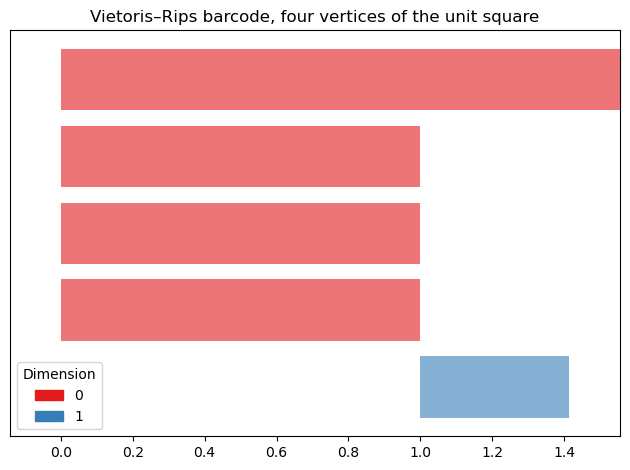

In [27]:
diag_sq = gudhi.RipsComplex(points=square, max_edge_length=2.0)\
    .create_simplex_tree(max_dimension=2).persistence()
ax = gudhi.plot_persistence_barcode(diag_sq, legend=True)
ax.set_title("Vietoris–Rips barcode, four vertices of the unit square")
plt.tight_layout(); plt.show()

---
## 4. Experiment 2 — noisy circle

The experiment is split into two parts that test **different things**, a distinction the earlier
draft did not make.

**(a) A test of Theorem 3.** On a fixed grid of $40$ scales we build the module
$H_1(K_1)\to\cdots\to H_1(K_{40})$ by hand and decompose it, then compare with GUDHI discretised to
the same grid. A finite grid is not a compromise here: the framework of the paper *is* a finite
filtration $K_1\subseteq\cdots\subseteq K_n$, i.e. a representation of $\vec{A}_n$.

**(b) An illustration, not a test of Theorem 3.** That one long bar appears at all is a consequence
of stability and sampling theorems, not of the interval decomposition. Theorem 3 says nothing about
how long any bar is. We report the behaviour over 100 independent samples instead of a single draw.

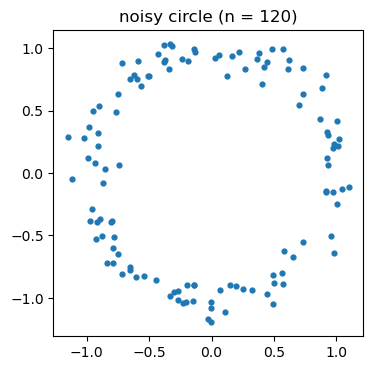

In [30]:
def sample_circle(rng, n=120, sigma=0.08):
    th = rng.uniform(0, 2*np.pi, n)
    return np.c_[np.cos(th), np.sin(th)] + rng.normal(0, sigma, (n, 2))


rng_circle = np.random.default_rng(SEED_CIRCLE)
circle = sample_circle(rng_circle, n=120)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(circle[:, 0], circle[:, 1], s=12)
ax.set_aspect("equal"); ax.set_title("noisy circle (n = 120)")
plt.show()

### (a) Hand-built module vs GUDHI

Building $H_1$ by hand costs $O(n^3)$ in the number of triangles, so this cell takes about a minute
at $n=120$. Set `N_MODULE = 60` for a fast pass; the conclusion is the same.

In [33]:
N_MODULE, N_GRID, RMAX = 120, 40, 1.8
X1 = circle[:N_MODULE]
grid_c = tda.grid_from_distances(None, N_GRID, RMAX)

t0 = time.time()
phis_c, dims_c = tda.h1_module(X1, grid_c)
A = Counter(qrep.decompose(phis_c, 2))
B = Counter(qrep.intervals_from_rank_invariant(phis_c, 2))
G = Counter(tda.discretise_barcode(gudhi_bars(X1, RMAX, 2, 1), grid_c))
EXP2_OK = (A == B == G)

print(f"n = {N_MODULE} points, {N_GRID} scales on [0, {RMAX}]   ({time.time()-t0:.1f} s)")
print("dim H_1(K_i) =", dims_c)
print(f"  A  hand-built module, reduction algorithm : {fmt_bars(A)}")
print(f"  B  hand-built module, rank invariant      : {fmt_bars(B)}")
print(f"  C  GUDHI, discretised to the same grid    : {fmt_bars(G)}")
print("\nidentical multisets:", EXP2_OK)

n = 120 points, 40 scales on [0, 1.8]   (95.5 s)
dim H_1(K_i) = [0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
  A  hand-built module, reduction algorithm : I[4,4]  I[5,5]  I[7,33]
  B  hand-built module, rank invariant      : I[4,4]  I[5,5]  I[7,33]
  C  GUDHI, discretised to the same grid    : I[4,4]  I[5,5]  I[7,33]

identical multisets: True


The agreement covers the short noise bars as well, not only the dominant one, and it is exact: the
two multisets are equal, not merely close. Note also that the number and position of the short bars
depends on the sample, so this is a fresh test on every seed, not a fixed target.

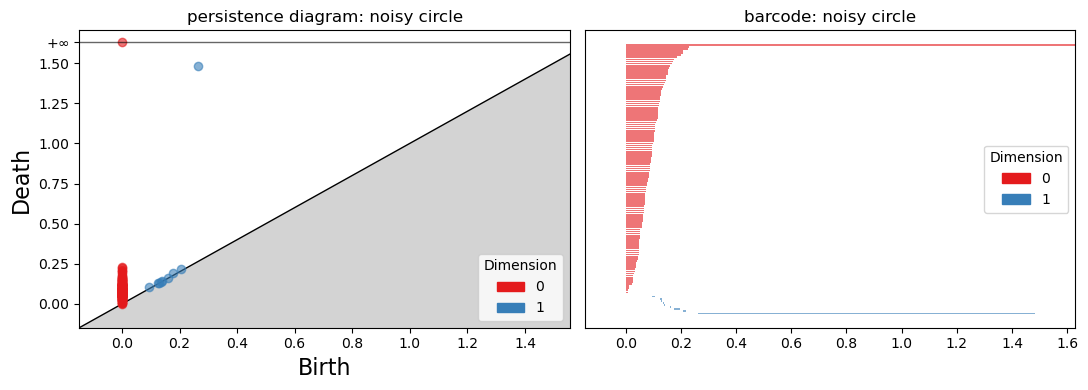

In [36]:
diag_c = gudhi.RipsComplex(points=circle, max_edge_length=2.5)\
    .create_simplex_tree(max_dimension=2).persistence()
fig = plt.figure(figsize=(11, 4))
ax = fig.add_subplot(1, 2, 1)
gudhi.plot_persistence_diagram(diag_c, legend=True, axes=ax)
ax.set_title("persistence diagram: noisy circle")
ax = fig.add_subplot(1, 2, 2)
gudhi.plot_persistence_barcode(diag_c, legend=True, max_intervals=1000, axes=ax)
ax.set_title("barcode: noisy circle")
plt.tight_layout(); plt.show()

### (b) How stable is the dominant bar?

A single draw tells us nothing about variability. We repeat the sampling 100 times with independent
generators and report medians and 5–95% ranges.

longest H_1 bar: length   median   1.2334   5–95% [1.1041, 1.3239]
                 birth    median   0.2830   5–95% [0.2202, 0.4252]
                 death    median   1.5231   5–95% [1.4486, 1.5776]
ratio longest/second      median  32.6602   5–95% [17.4277, 67.8270]
number of H_1 bars        median  10.0000   5–95% [6.0000, 15.0000]

dominant bar exceeds the runner-up in 100/100 samples; smallest ratio observed 11.56


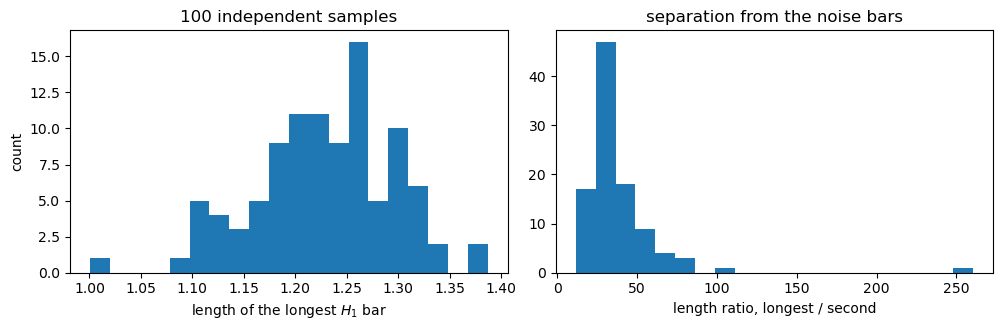

In [39]:
SEEDS = 100
lengths, births, deaths, ratios, counts = [], [], [], [], []
for s in range(SEEDS):
    Y = sample_circle(np.random.default_rng(90000 + s), n=120)
    bars = sorted(gudhi_bars(Y, 2.5, 2, 1), key=lambda t: t[1]-t[0], reverse=True)
    b, d = bars[0]
    counts.append(len(bars)); lengths.append(d-b); births.append(b); deaths.append(d)
    ratios.append((d-b)/(bars[1][1]-bars[1][0]))

for name, v in [("longest H_1 bar: length", lengths), ("                 birth", births),
                ("                 death", deaths), ("ratio longest/second", ratios),
                ("number of H_1 bars", counts)]:
    q = quantiles(v)
    print(f"{name:<25} median {q[1]:8.4f}   5–95% [{q[0]:.4f}, {q[2]:.4f}]")
print(f"\ndominant bar exceeds the runner-up in {sum(r > 1 for r in ratios)}/{SEEDS} samples; "
      f"smallest ratio observed {min(ratios):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(lengths, bins=20); axes[0].set_xlabel("length of the longest $H_1$ bar")
axes[0].set_ylabel("count"); axes[0].set_title(f"{SEEDS} independent samples")
axes[1].hist(ratios, bins=20); axes[1].set_xlabel("length ratio, longest / second")
axes[1].set_title("separation from the noise bars")
plt.tight_layout(); plt.show()

---
## 5. Experiment 3 — two Gaussian clusters

Again in two parts.

**(a)** The $H_0$ module built by union-find, decomposed, and compared with GUDHI on a grid of 60
scales — a test of Theorem 3 with 120 intervals to match, not just the two long ones.

**(b)** A prediction sharper than the one in the draft. The draft says the second bar dies at a
scale "matching the observed inter-cluster gap". In fact the statement is an exact identity:
persistent $H_0$ of a Vietoris–Rips filtration is single-linkage clustering, so the second death is
**equal** to $\min\{\lVert x-y\rVert : x\in C_1,\ y\in C_2\}$. Equality to machine precision is
falsifiable; "matching" is not.

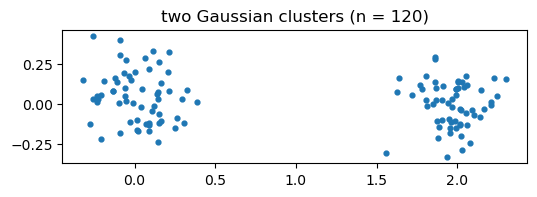

In [42]:
def sample_clusters(rng, n_each=60, sigma=0.15, sep=2.0):
    return (rng.normal([0, 0], sigma, (n_each, 2)),
            rng.normal([sep, 0], sigma, (n_each, 2)))


rng_clusters = np.random.default_rng(SEED_CLUSTERS)
c1, c2 = sample_clusters(rng_clusters)
clusters = np.vstack([c1, c2])

fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(clusters[:, 0], clusters[:, 1], s=12)
ax.set_aspect("equal"); ax.set_title("two Gaussian clusters (n = 120)")
plt.show()

In [44]:
N_GRID_K, RMAX_K = 60, 1.4
grid_k = tda.grid_from_distances(None, N_GRID_K, RMAX_K)
phis_k, dims_k = tda.h0_module(clusters, grid_k)
A = Counter(qrep.decompose(phis_k, 2))
B = Counter(qrep.intervals_from_rank_invariant(phis_k, 2))
G = Counter(tda.discretise_barcode(gudhi_bars(clusters, 3.0, 1, 0), grid_k))
EXP3_OK = (A == B == G)

print(f"{N_GRID_K} scales on [0, {RMAX_K}];  dim H_0(K_i) = "
      f"{dims_k[0]}, {dims_k[1]}, ..., {dims_k[-1]}")
print(f"number of intervals: A {sum(A.values())}, B {sum(B.values())}, GUDHI {sum(G.values())}")
print("intervals of index-length >= 15:",
      fmt_bars(Counter({k: v for k, v in A.items() if k[1]-k[0] >= 15})))
print("\nidentical multisets:", EXP3_OK)

60 scales on [0, 1.4];  dim H_0(K_i) = 120, 102, ..., 1
number of intervals: A 120, B 120, GUDHI 120
intervals of index-length >= 15: I[1,51]  I[1,60]

identical multisets: True


In [46]:
SEEDS = 100
exact, gaps, d2s, d3s, ratio = 0, [], [], [], []
for s in range(SEEDS):
    a, b = sample_clusters(np.random.default_rng(70000 + s))
    bars = sorted(gudhi_bars(np.vstack([a, b]), 3.0, 1, 0),
                  key=lambda t: t[1]-t[0], reverse=True)
    d2, d3 = bars[1][1], bars[2][1]
    gap = float(np.sqrt(((a[:, None, :] - b[None, :, :])**2).sum(-1)).min())
    exact += abs(d2 - gap) < 1e-12
    gaps.append(gap); d2s.append(d2); d3s.append(d3); ratio.append(d2/d3)

print(f"second H_0 death == single-linkage gap to within 1e-12 in {exact}/{SEEDS} samples")
for name, v in [("second death d_2", d2s), ("inter-cluster gap", gaps),
                ("third death d_3", d3s), ("d_2 / d_3", ratio)]:
    q = quantiles(v)
    print(f"{name:<20} median {q[1]:8.4f}   5–95% [{q[0]:.4f}, {q[2]:.4f}]")

GAP_OK = (exact == SEEDS)

second H_0 death == single-linkage gap to within 1e-12 in 100/100 samples
second death d_2     median   1.3276   5–95% [1.1570, 1.4551]
inter-cluster gap    median   1.3276   5–95% [1.1570, 1.4551]
third death d_3      median   0.1975   5–95% [0.1522, 0.3103]
d_2 / d_3            median   6.5717   5–95% [3.9543, 8.9616]


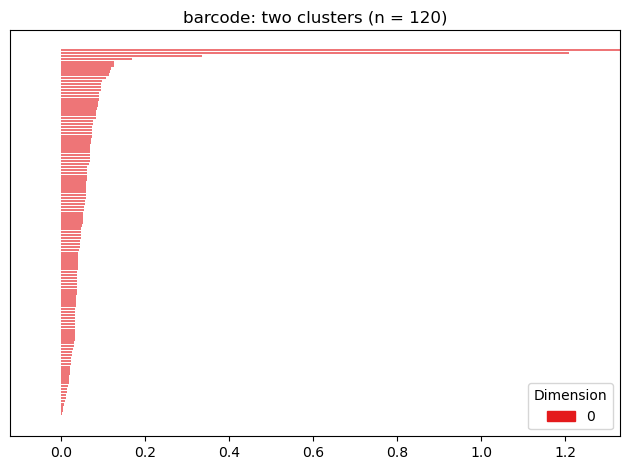

In [48]:
diag_k = gudhi.RipsComplex(points=clusters, max_edge_length=3.0)\
    .create_simplex_tree(max_dimension=1).persistence()
ax = gudhi.plot_persistence_barcode(diag_k, legend=True, max_intervals=1000)
ax.set_title("barcode: two clusters (n = 120)")
plt.tight_layout(); plt.show()

---
## 6. A reproducibility note on the random number generator

The earlier draft of this notebook created one generator, `rng = np.random.default_rng(2026)`, and
drew from it in Experiment 2 and then again in Experiment 3. A generator is stateful, so the data of
Experiment 3 depend on how many numbers Experiment 2 consumed. Editing Experiment 2, or re-running
cells out of order, silently changes Experiment 3. The cell numbering of that draft
(`In [3], [6], [8], [12], …`) shows it was not executed as a single top-to-bottom pass.

The cell below makes the effect explicit.

In [51]:
def second_h0_death(X):
    bars = sorted(gudhi_bars(X, 3.0, 1, 0), key=lambda t: t[1]-t[0], reverse=True)
    return bars[1][1]


r = np.random.default_rng(2026)                      # as in the earlier draft
th = r.uniform(0, 2*np.pi, 120)
_ = np.c_[np.cos(th), np.sin(th)] + r.normal(0, 0.08, (120, 2))   # Experiment 2 draws
a1, b1 = sample_clusters(r)

r = np.random.default_rng(2026)                      # same seed, Experiment 2 skipped
a2, b2 = sample_clusters(r)

print(f"Experiment 3 after Experiment 2 : second H_0 death = "
      f"{second_h0_death(np.vstack([a1, b1])):.10f}")
print(f"Experiment 3 on its own         : second H_0 death = "
      f"{second_h0_death(np.vstack([a2, b2])):.10f}")
print("same point cloud:", np.allclose(a1, a2))
print("\nRemedy: one generator per experiment, with the seeds stated in the paper.")

Experiment 3 after Experiment 2 : second H_0 death = 1.1462268553
Experiment 3 on its own         : second H_0 death = 1.1129288532
same point cloud: False

Remedy: one generator per experiment, with the seeds stated in the paper.


A second consequence: the value $1.1462$ reported in the earlier draft sits **below the 5th
percentile** of the distribution measured in Section 5 (median $\approx 1.33$, 5–95% range
$\approx[1.16,1.46]$). It is not an error, but it is not a typical draw either, which is the reason
for reporting a distribution rather than a single number.

---
## 7. Summary

In [55]:
results = {
    "Proposition 1: positive roots are the interval vectors (n <= 8)": PROP1_OK,
    "Proposition 2 algorithm agrees with the rank invariant, GF(2,3,5)": ALGO_OK,
    "Theorem 3 uniqueness: invariant under basis change and reordering": ALGO_OK,
    "Experiment 1: four independent routes agree (unit square)": EXP1_OK,
    "Experiment 2: hand-built H_1 module agrees with GUDHI": EXP2_OK,
    "Experiment 3: hand-built H_0 module agrees with GUDHI": EXP3_OK,
    "Experiment 3: second death == single-linkage gap, 100/100 samples": GAP_OK,
}
for k, v in results.items():
    print(("PASS  " if v else "FAIL  ") + k)
print("\nall checks passed:", all(results.values()))

PASS  Proposition 1: positive roots are the interval vectors (n <= 8)
PASS  Proposition 2 algorithm agrees with the rank invariant, GF(2,3,5)
PASS  Theorem 3 uniqueness: invariant under basis change and reordering
PASS  Experiment 1: four independent routes agree (unit square)
PASS  Experiment 2: hand-built H_1 module agrees with GUDHI
PASS  Experiment 3: hand-built H_0 module agrees with GUDHI
PASS  Experiment 3: second death == single-linkage gap, 100/100 samples

all checks passed: True


### What is, and is not, established

**Established.** The multiset of intervals obtained from a persistence module by the reduction
algorithm of Proposition 2 coincides with the barcode computed by GUDHI's boundary-matrix
reduction, on every data set tested, including multiplicities; it also coincides with the intervals
recovered from the rank invariant, a computation involving no basis choice. The multiset is
unchanged by any of the arbitrary choices the algorithm makes, which is the content of the
uniqueness assertion of Theorem 3. The positive roots of $q_{A_n}$ are the interval vectors.

**Not established here, and not claimed.** That a noisy sample of a circle produces one long
$H_1$ bar does not follow from Theorem 3; it follows from stability and sampling results
(Cohen-Steiner–Edelsbrunner–Harer; Niyogi–Smale–Weinberger), which the paper should cite where it
makes that claim. Theorem 3 constrains the *form* of the decomposition, never the lengths of the
bars.

**Left to the authors.** A theoretical threshold for the death of the $H_1$ bar of a densely
sampled circle exists in the literature on Vietoris–Rips complexes of the circle
(Adamaszek–Adams); it is deliberately not used above, since the reference has not been checked
here. Verify it at the source before putting a number in the paper.